# Road Closure Duration & Secondary Congestion Prediction

**Domain:** Emergency Dispatch & Traffic Physics  
**Dataset:** `synthetic_traffic_benchmark_200k.csv` (200,000 records, 29 features)  
**Target Variable:** `Road_Closure_Duration_min`

---

## Problem Statement

When a traffic accident occurs, road management authorities face a critical operational window between the moment of incident detection and the restoration of normal traffic flow. During this window, failure to accurately estimate the road closure duration leads to cascading secondary congestion, misallocation of emergency resources, and delayed rerouting of vehicles.

This notebook builds a full supervised regression pipeline to predict `Road_Closure_Duration_min` the total duration in minutes that a road segment remains closed following an accident. The modeling scope is intentionally restricted to the accident subset of the dataset (`Accident_Occurred == 1`), since closure duration is physically undefined for non-accident records.

The pipeline follows production-grade standards:

- Scoped data extraction and cleaning from the raw 200k-record benchmark
- Physics-informed feature engineering (kinetic energy index, braking distance proxy, friction coefficient, speed deviation)
- Categorical encoding and preprocessing within a `sklearn` Pipeline to prevent data leakage
- Benchmarking of four regression models: Ridge Regression, Random Forest, XGBoost, and LightGBM
- Hyperparameter tuning via Randomized Search with cross-validation
- Evaluation using RMSE, MAE, MAPE, and R-squared
- SHAP-based global and local explainability analysis
- Serialization of all model artifacts and metadata for deployment and reproducibility

---

## Table of Contents

1. [Library Imports](#1)
2. [Configuration & Reproducibility](#2)
3. [Data Loading & Scoping](#3)
4. [Data Cleaning](#4)
5. [Exploratory Data Analysis](#5)
6. [Physics-Informed Feature Engineering](#6)
7. [Preprocessing Pipeline Definition](#7)
8. [Model Training & Benchmarking](#8)
9. [Hyperparameter Tuning](#9)
10. [Final Model Evaluation](#10)
11. [SHAP Explainability](#11)
12. [Artifact Serialization](#12)


---

<a id='1'></a>

## 1. Library Imports

All dependencies are imported upfront. The library stack covers data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), machine learning (`scikit-learn`, `xgboost`, `lightgbm`), model explainability (`shap`), and artifact persistence (`joblib`, `json`).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import shap

ARTIFACT_DIR = './model_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print('All libraries loaded successfully.')
print(f'Artifact directory: {os.path.abspath(ARTIFACT_DIR)}')


All libraries loaded successfully.
Artifact directory: c:\Users\admin\Documents\Portofolio\Emergency Dispatch & Traffic Physics\Model\model_artifacts


---

<a id='2'></a>

## 2. Configuration & Reproducibility

A centralized configuration block is defined here to ensure that every stochastic component from data splitting to model training can be reproduced exactly from the same seed. All paths, constants, and hyperparameter search budgets are declared in a single location to simplify future maintenance.


In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = '../Dataset/synthetic_traffic_benchmark_200k.csv'

TARGET_COL = 'Road_Closure_Duration_min'

TEST_SIZE = 0.20
VAL_SIZE  = 0.10

CV_FOLDS      = 5
N_ITER_SEARCH = 60

FRICTION_MAP = {
    'dry':            0.75,
    'wet':            0.42,
    'snowy':          0.28,
    'icy':            0.10,
    'standing water': 0.35,
}

VEHICLE_MASS_MAP = {
    'sedan':      1400,
    'suv':        2000,
    'truck':      8000,
    'motorcycle':  220,
    'bus':        12000,
}

SEVERITY_ORDER  = ['Minor', 'Moderate', 'Severe', 'Fatal']
COLLISION_ORDER = ['Single-Vehicle', 'Rear-End', 'Side-Impact', 'Head-On']
PRIORITY_ORDER  = ['Standard', 'Medium', 'High']

PLOT_STYLE = {
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
}
plt.rcParams.update(PLOT_STYLE)
PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657']

print('Configuration set. Random seed:', RANDOM_SEED)


Configuration set. Random seed: 42


---

<a id='3'></a>

## 3. Data Loading & Scoping

The full 200,000-record dataset is loaded and then immediately scoped to the accident subset (`Accident_Occurred == 1`). This yields **8,231 records** where the target variable is physically defined and non-zero.

Columns that are definitionally redundant for this regression task are dropped:

- `Record_ID`, `Timestamp`, `Date`: raw identifiers with no predictive signal after temporal feature extraction.
- `Accident_Occurred`: constant (all 1) within this subset.

Note: `Actual_Response_Time_min` is retained as a feature intentionally. In a real dispatch system, this represents the elapsed response time at the time of prediction (a state variable), not a future outcome, and therefore does not constitute target leakage.


In [3]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Full dataset shape: {df_raw.shape}')

df = df_raw[df_raw['Accident_Occurred'] == 1].copy()
print(f'Accident subset shape: {df.shape}')
print(f'Target range: [{df[TARGET_COL].min():.1f}, {df[TARGET_COL].max():.1f}] minutes')

COLS_TO_DROP = ['Record_ID', 'Timestamp', 'Date', 'Accident_Occurred']
df.drop(columns=COLS_TO_DROP, inplace=True)

print(f'\nWorking dataset shape after dropping identifiers: {df.shape}')
df.head(3)


Full dataset shape: (200000, 29)
Accident subset shape: (8231, 29)
Target range: [55.6, 1772.5] minutes

Working dataset shape after dropping identifiers: (8231, 25)


,Hour,Month,Day_of_Week,Time_of_Day,Is_Holiday,Area_Type,Road_Type,Intersection_Type,Speed_Limit_kmh,Weather,...,Driver_Experience_yrs,Vehicle_Age_yrs,Recorded_Speed_kmh,Baseline_Expected_Response_Time_min,Collision_Type,Vehicles_Involved,Accident_Severity,Dispatch_Priority,Actual_Response_Time_min,Road_Closure_Duration_min
22,19,6,Monday,Evening Peak,1,Suburban,Interstate,NaN,100,Rain,...,19.4,1.6,76.3,9.7,Rear-End,2,Minor,Standard,24.7,117.6
34,13,5,Tuesday,Midday,0,Rural,Interstate,NaN,120,Clear,...,4.0,11.3,112.7,25.0,Rear-End,2,Severe,High,36.4,524.7
40,11,2,Tuesday,Midday,0,Urban,Local,4-Way,30,Snow,...,3.0,2.6,15.3,3.0,Rear-End,2,Minor,Standard,14.3,143.2


---

<a id='4'></a>

## 4. Data Cleaning

### 4.1 Missing Value Audit

A structured audit is performed to identify columns with missing values, their absolute counts, and percentage of total records.


In [4]:
missing     = df.isnull().sum()
missing     = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)':   missing_pct,
    'Dtype':         df[missing.index].dtypes
})

print('Columns with missing values:')
display(missing_df)


Columns with missing values:


,Missing Count,Missing (%),Dtype
Intersection_Type,3596,43.69,str
Visibility_m,264,3.21,float64
Driver_Experience_yrs,144,1.75,float64


### 4.2 String Normalization

Raw string columns contain inconsistent casing and whitespace artifacts (e.g., `Rain`, `RAIN`, ` rain `). All categorical columns are stripped and title-cased to consolidate duplicate category levels before encoding.


In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

df['Intersection_Type'] = df['Intersection_Type'].replace('Nan', np.nan)

print('Unique values per categorical column after normalization:')
for col in cat_cols:
    print(f'  {col}: {sorted(df[col].dropna().unique().tolist())}')


Unique values per categorical column after normalization:
  Day_of_Week: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
  Time_of_Day: ['Evening Peak', 'Midday', 'Morning Peak', 'Night']
  Area_Type: ['Rural', 'Suburban', 'Urban']
  Road_Type: ['Arterial', 'Collector', 'Interstate', 'Local']
  Intersection_Type: ['4-Way', 'Roundabout', 'T-Junction']
  Weather: ['Clear', 'Fog', 'Rain', 'Snow']
  Road_Condition: ['Dry', 'Icy', 'Snowy', 'Standing Water', 'Wet']
  Vehicle_Type: ['Bus', 'Motorcycle', 'Sedan', 'Suv', 'Truck']
  Collision_Type: ['Head-On', 'Rear-End', 'Side-Impact', 'Single-Vehicle']
  Accident_Severity: ['Fatal', 'Minor', 'Moderate', 'Severe']
  Dispatch_Priority: ['High', 'Medium', 'Standard']


### 4.3 Outlier Capping (Winsorization)

The target variable `Road_Closure_Duration_min` exhibits a right-skewed distribution with a long tail (max ~1772 minutes). A percentile-based capping strategy (Winsorization at the 1st and 99th percentile) is applied to the target and to high-variance numerical features. The original target is preserved as `Road_Closure_Duration_min_raw` for reference.


In [6]:
df['Road_Closure_Duration_min_raw'] = df[TARGET_COL].copy()

cap_cols = [TARGET_COL, 'Recorded_Speed_kmh', 'Visibility_m', 'Congestion_Index']

clip_bounds = {}
for col in cap_cols:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    clip_bounds[col] = (lo, hi)
    df[col] = df[col].clip(lower=lo, upper=hi)

print('Winsorization bounds applied:')
for col, (lo, hi) in clip_bounds.items():
    print(f'  {col}: [{lo:.2f}, {hi:.2f}]')

print(f'\nTarget after capping: mean={df[TARGET_COL].mean():.1f}, std={df[TARGET_COL].std():.1f}, max={df[TARGET_COL].max():.1f}')


Winsorization bounds applied:
  Road_Closure_Duration_min: [70.80, 871.34]
  Recorded_Speed_kmh: [16.93, 128.90]
  Visibility_m: [185.03, 14165.67]
  Congestion_Index: [9.00, 100.00]

Target after capping: mean=183.2, std=128.9, max=871.3


---

<a id='5'></a>

## 5. Exploratory Data Analysis

Before feature engineering, the relationships between the target and the most informative raw features are visualized. Key patterns to validate:

- The target distribution (right-skewed; justifies log-transform consideration)
- Monotonic relationship between accident severity and closure duration
- Collision type hierarchy by closure duration magnitude
- Correlation heatmap of numerical predictors


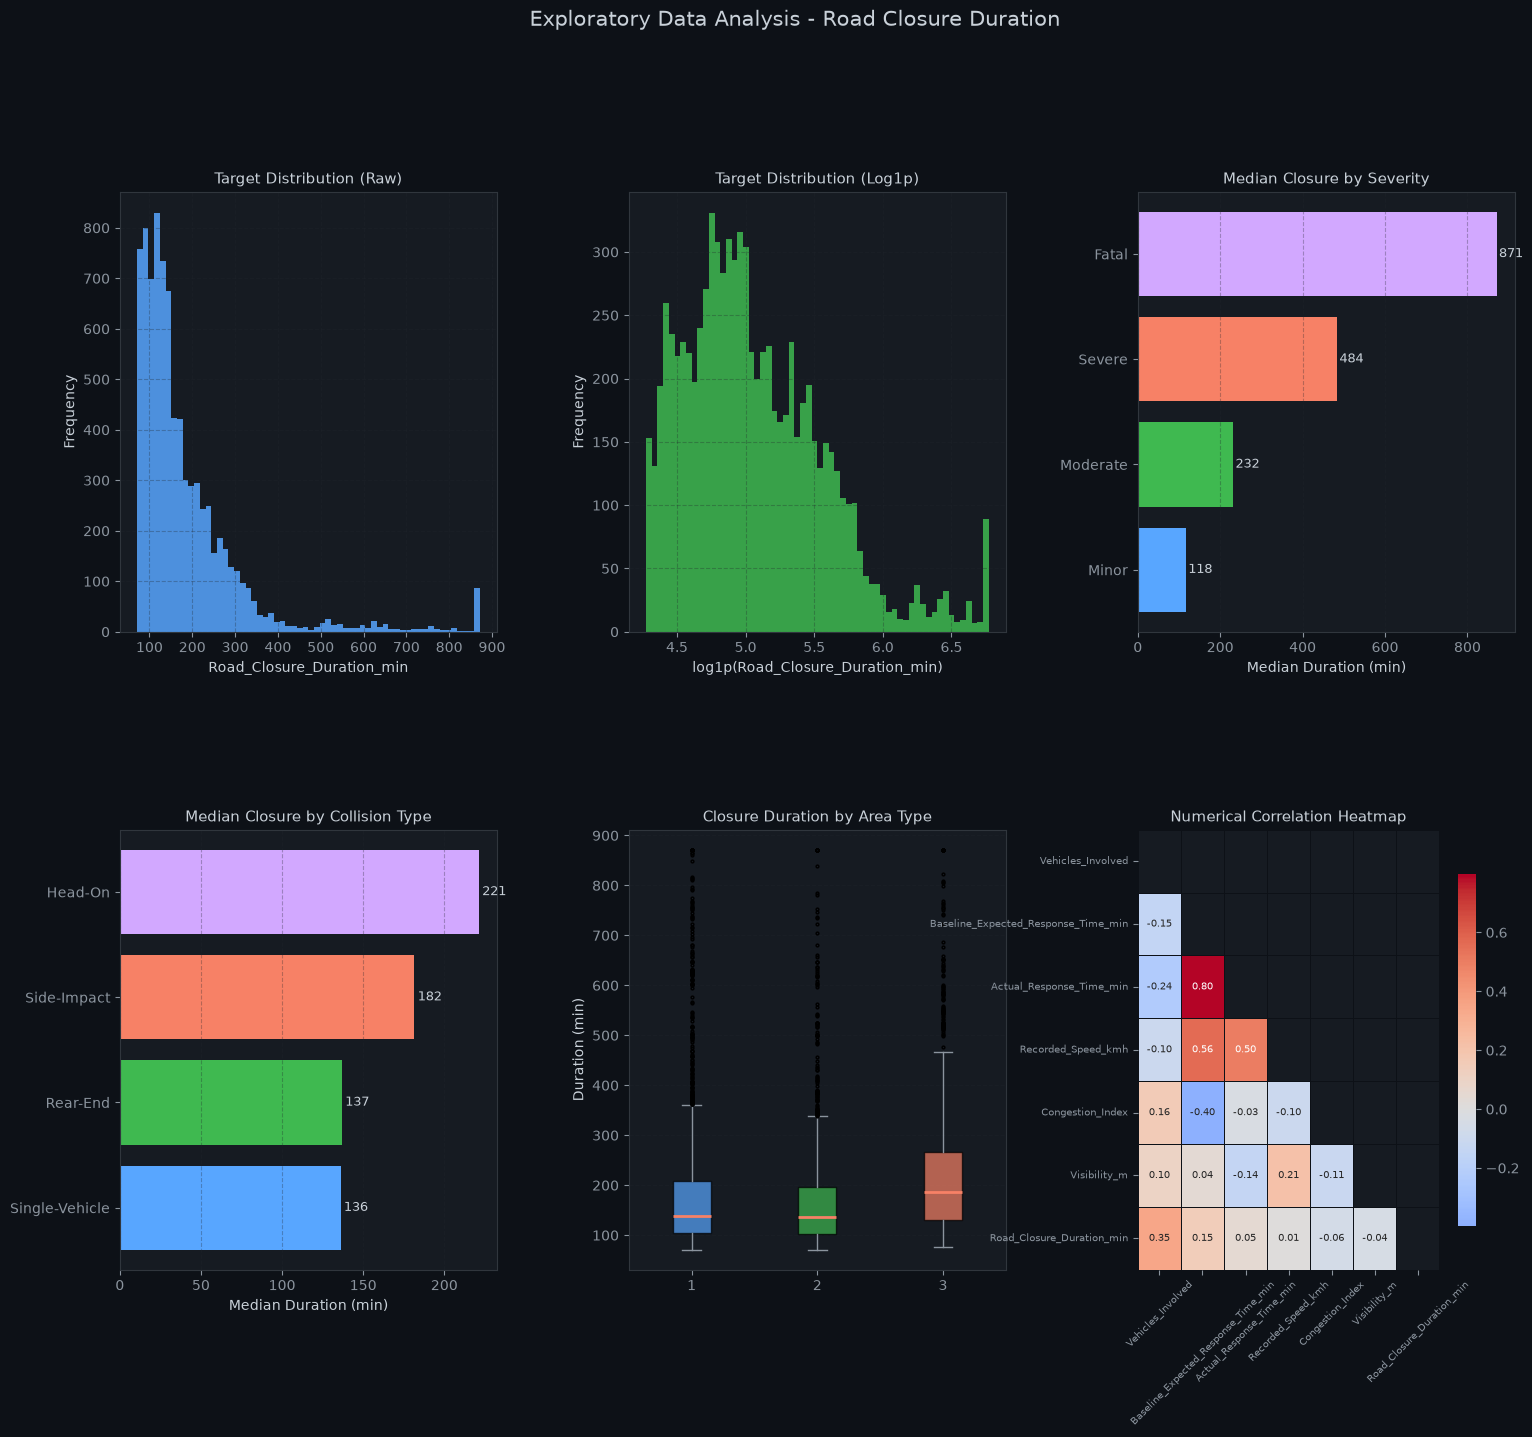

EDA plot saved to artifact directory.


In [8]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Exploratory Data Analysis - Road Closure Duration', fontsize=15, color='#c9d1d9', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df[TARGET_COL], bins=60, color=PALETTE[0], edgecolor='none', alpha=0.85)
ax1.set_title('Target Distribution (Raw)', fontsize=11)
ax1.set_xlabel('Road_Closure_Duration_min')
ax1.set_ylabel('Frequency')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(np.log1p(df[TARGET_COL]), bins=60, color=PALETTE[1], edgecolor='none', alpha=0.85)
ax2.set_title('Target Distribution (Log1p)', fontsize=11)
ax2.set_xlabel('log1p(Road_Closure_Duration_min)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
severity_means = df.groupby('Accident_Severity')[TARGET_COL].median().reindex(SEVERITY_ORDER)
bars3 = ax3.barh(SEVERITY_ORDER, severity_means.values, color=PALETTE[:4], edgecolor='none')
ax3.set_title('Median Closure by Severity', fontsize=11)
ax3.set_xlabel('Median Duration (min)')
for bar, val in zip(bars3, severity_means.values):
    ax3.text(val + 5, bar.get_y() + bar.get_height() / 2, f'{val:.0f}', va='center', fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

ax4 = fig.add_subplot(gs[1, 0])
collision_means = df.groupby('Collision_Type')[TARGET_COL].median().reindex(COLLISION_ORDER)
bars4 = ax4.barh(COLLISION_ORDER, collision_means.values, color=PALETTE[:4], edgecolor='none')
ax4.set_title('Median Closure by Collision Type', fontsize=11)
ax4.set_xlabel('Median Duration (min)')
for bar, val in zip(bars4, collision_means.values):
    ax4.text(val + 2, bar.get_y() + bar.get_height() / 2, f'{val:.0f}', va='center', fontsize=9)
ax4.grid(True, alpha=0.3, axis='x')

ax5 = fig.add_subplot(gs[1, 1])
area_data = [df[df['Area_Type'] == a][TARGET_COL].values for a in ['Urban', 'Suburban', 'Rural']]
bp = ax5.boxplot(
    area_data, label=['Urban', 'Suburban', 'Rural'], patch_artist=True,
    medianprops={'color': '#f78166', 'linewidth': 2},
    whiskerprops={'color': '#8b949e'},
    capprops={'color': '#8b949e'},
    flierprops={'marker': 'o', 'color': '#8b949e', 'markersize': 2}
)
for patch, color in zip(bp['boxes'], PALETTE[:3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax5.set_title('Closure Duration by Area Type', fontsize=11)
ax5.set_ylabel('Duration (min)')
ax5.grid(True, alpha=0.3, axis='y')

ax6 = fig.add_subplot(gs[1, 2])
num_for_corr = ['Vehicles_Involved', 'Baseline_Expected_Response_Time_min',
                'Actual_Response_Time_min', 'Recorded_Speed_kmh',
                'Congestion_Index', 'Visibility_m', TARGET_COL]
corr_matrix = df[num_for_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax6, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, linecolor='#0d1117', cbar_kws={'shrink': 0.8})
ax6.set_title('Numerical Correlation Heatmap', fontsize=11)
ax6.tick_params(axis='x', rotation=45, labelsize=7)
ax6.tick_params(axis='y', rotation=0,  labelsize=7)

plt.savefig(f'{ARTIFACT_DIR}/eda_overview.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('EDA plot saved to artifact directory.')


---

<a id='6'></a>

## 6. Physics-Informed Feature Engineering

Raw feature correlations with the target are weak (max linear correlation ~0.34 for `Vehicles_Involved`). To improve model signal, domain-informed composite features are constructed based on traffic physics principles.

| New Feature | Formula / Derivation | Physical Rationale |
|---|---|---|
| `friction_coeff` | Mapped from `Road_Condition` | Lower friction implies longer skid marks, higher debris scatter, longer cleanup |
| `stopping_distance_m` | v^2 / (2 * mu * g), v in m/s | Proxy for collision severity and scene extent |
| `kinetic_energy_kJ` | 0.5 * m * (v/3.6)^2 / 1000 | Energy to dissipate correlates with physical damage and cleanup time |
| `speed_deviation` | Recorded_Speed - Speed_Limit | Speeding magnitude as a collision severity amplifier |
| `speed_deviation_sq` | (speed_deviation)^2 | Non-linear amplification of high-speed deviations |
| `response_delay` | Actual - Baseline Response Time | Indicates scene access difficulty or secondary incidents |
| `driver_inexperience` | 1 / (Experience_yrs + 1) | Hazard proxy: inverse experience weighting |
| `low_visibility_flag` | 1 if Visibility < 500m | Boolean indicator of severely impaired visibility |
| `hour_sin`, `hour_cos` | Cyclical encoding of Hour | Preserves circular time-of-day continuity |
| `month_sin`, `month_cos` | Cyclical encoding of Month | Preserves seasonal cyclicality |


In [9]:
G = 9.81

df['friction_coeff'] = (
    df['Road_Condition'].str.lower().str.strip()
    .map(FRICTION_MAP)
    .fillna(0.50)
)

v_ms = df['Recorded_Speed_kmh'] / 3.6
df['stopping_distance_m'] = (v_ms ** 2) / (2 * df['friction_coeff'] * G)

df['vehicle_mass_kg'] = (
    df['Vehicle_Type'].str.lower().str.strip()
    .map(VEHICLE_MASS_MAP)
    .fillna(1400)
)
df['kinetic_energy_kJ'] = 0.5 * df['vehicle_mass_kg'] * (v_ms ** 2) / 1000

df['speed_deviation']    = df['Recorded_Speed_kmh'] - df['Speed_Limit_kmh']
df['speed_deviation_sq'] = df['speed_deviation'] ** 2

df['response_delay'] = df['Actual_Response_Time_min'] - df['Baseline_Expected_Response_Time_min']

df['driver_inexperience'] = 1.0 / (df['Driver_Experience_yrs'].fillna(df['Driver_Experience_yrs'].median()) + 1)

df['low_visibility_flag'] = (df['Visibility_m'] < 500).astype(int)

df['hour_sin']  = np.sin(2 * np.pi * df['Hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['Hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

new_features = [
    'friction_coeff', 'stopping_distance_m', 'vehicle_mass_kg',
    'kinetic_energy_kJ', 'speed_deviation', 'speed_deviation_sq',
    'response_delay', 'driver_inexperience', 'low_visibility_flag',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]
print(f'Engineered {len(new_features)} new features:')
display(df[new_features].describe().T[['mean', 'std', 'min', 'max']].round(3))


Engineered 13 new features:


,mean,std,min,max
friction_coeff,0.543,0.218,0.100,0.750
stopping_distance_m,29.452,28.611,1.503,303.169
vehicle_mass_kg,2329.015,2378.726,220.000,12000.000
kinetic_energy_kJ,323.902,509.127,2.433,5128.151
speed_deviation,-14.109,14.728,-103.070,78.900
speed_deviation_sq,415.948,653.978,0.000,10623.425
response_delay,9.943,4.993,0.000,31.000
driver_inexperience,0.211,0.267,0.020,1.000
low_visibility_flag,0.076,0.265,0.000,1.000
hour_sin,-0.067,0.807,-1.000,1.000


---

<a id='7'></a>

## 7. Preprocessing Pipeline Definition

### 7.1 Feature Set Definition

Features are partitioned into three groups for distinct preprocessing treatment:

- **Numerical features**: imputed (median strategy) and scaled with `StandardScaler`.
- **Ordinal categorical features**: encoded with a known severity/priority order using `OrdinalEncoder`.
- **Nominal categorical features**: encoded with `OrdinalEncoder` in frequency-agnostic mode (used with tree-based models that handle integer-encoded categories natively).

### 7.2 Target Transformation

Because the target is right-skewed (skewness > 2 even after winsorization), a `log1p` transformation is applied to compress the tail and reduce the influence of large values on MSE-based loss functions. All evaluation metrics are reported in the original scale after applying `expm1` back-transformation.


In [10]:
NUMERICAL_FEATURES = [
    'Speed_Limit_kmh', 'Congestion_Index', 'Driver_Age',
    'Vehicle_Age_yrs', 'Recorded_Speed_kmh',
    'Baseline_Expected_Response_Time_min', 'Actual_Response_Time_min',
    'Vehicles_Involved', 'Visibility_m',
    'friction_coeff', 'stopping_distance_m', 'kinetic_energy_kJ',
    'speed_deviation', 'speed_deviation_sq', 'response_delay',
    'driver_inexperience', 'low_visibility_flag',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Is_Holiday',
]

ORDINAL_FEATURES   = ['Accident_Severity', 'Dispatch_Priority']
ORDINAL_CATEGORIES = [SEVERITY_ORDER, PRIORITY_ORDER]

NOMINAL_FEATURES = ['Area_Type', 'Road_Type', 'Intersection_Type',
                    'Weather', 'Road_Condition', 'Vehicle_Type']

ALL_FEATURES = NUMERICAL_FEATURES + ORDINAL_FEATURES + NOMINAL_FEATURES

X     = df[ALL_FEATURES].copy()
y_raw = df[TARGET_COL].copy()
y     = np.log1p(y_raw)

print(f'Feature matrix shape: {X.shape}')
print(f'Target skewness (raw):     {stats.skew(y_raw):.3f}')
print(f'Target skewness (log1p):   {stats.skew(y):.3f}')

numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ORDINAL_CATEGORIES,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, NUMERICAL_FEATURES),
    ('ord', ordinal_transformer,   ORDINAL_FEATURES),
    ('nom', nominal_transformer,   NOMINAL_FEATURES),
], remainder='drop')

print('\nPreprocessor defined successfully.')


Feature matrix shape: (8231, 30)
Target skewness (raw):     2.939
Target skewness (log1p):   0.907

Preprocessor defined successfully.


### 7.3 Train / Validation / Test Split

The dataset is split into three non-overlapping partitions:

- **Train (70%)**: used for model fitting and cross-validation.
- **Validation (10%)**: used during hyperparameter search for early stopping guidance.
- **Test (20%)**: held out completely until final evaluation, never touched during training or tuning.


In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

val_fraction = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_fraction, random_state=RANDOM_SEED
)

print(f'Train set:      {X_train.shape[0]:>5} records ({X_train.shape[0] / len(X) * 100:.1f}%)')
print(f'Validation set: {X_val.shape[0]:>5} records ({X_val.shape[0]   / len(X) * 100:.1f}%)')
print(f'Test set:       {X_test.shape[0]:>5} records ({X_test.shape[0]  / len(X) * 100:.1f}%)')


Train set:       5761 records (70.0%)
Validation set:   823 records (10.0%)
Test set:        1647 records (20.0%)


---

<a id='8'></a>

## 8. Model Training & Benchmarking

Four regression models are benchmarked using 5-fold cross-validation on the training set. Each model is wrapped in a full `sklearn` Pipeline that includes the preprocessing step.

| Model | Rationale |
|---|---|
| **Ridge Regression** | Linear baseline; establishes minimum expected performance and reveals linear feature utility |
| **Random Forest Regressor** | Ensemble of decision trees; robust to outliers and non-linear relationships |
| **XGBoost Regressor** | Gradient boosting with L1/L2 regularization; strong tabular data performance |
| **LightGBM Regressor** | Leaf-wise gradient boosting; computationally efficient on this dataset scale |

Cross-validation scoring uses negative RMSE (`neg_root_mean_squared_error`), reported as positive RMSE on the log-scale target.


In [12]:
def evaluate_on_set(pipeline, X_te, y_te_log):
    y_pred_log = pipeline.predict(X_te)
    y_pred     = np.expm1(y_pred_log)
    y_true     = np.expm1(y_te_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R2': r2}

base_models = {
    'Ridge': Ridge(alpha=10.0, random_state=RANDOM_SEED),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_SEED
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, tree_method='hist', verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=400, learning_rate=0.04, max_depth=7,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, verbosity=-1
    ),
}

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
benchmark_results = []
fitted_baselines  = {}

for name, estimator in base_models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    cv_scores   = cross_val_score(pipe, X_train, y_train,
                                  cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_rmse_log = -cv_scores.mean()
    cv_std_log  =  cv_scores.std()
    pipe.fit(X_train, y_train)
    fitted_baselines[name] = pipe
    vm = evaluate_on_set(pipe, X_val, y_val)
    benchmark_results.append({
        'Model':               name,
        'CV RMSE (log-scale)': round(cv_rmse_log, 5),
        'CV Std':              round(cv_std_log,  5),
        'Val RMSE (min)':      round(vm['RMSE'], 2),
        'Val MAE (min)':       round(vm['MAE'],  2),
        'Val MAPE (%)':        round(vm['MAPE (%)'], 2),
        'Val R2':              round(vm['R2'],  4),
    })
    print(f'[{name}] CV RMSE(log): {cv_rmse_log:.5f} +/- {cv_std_log:.5f} | '
          f'Val RMSE: {vm["RMSE"]:.2f} min | R2: {vm["R2"]:.4f}')

benchmark_df = (pd.DataFrame(benchmark_results)
                .set_index('Model')
                .sort_values('Val RMSE (min)'))
print('\n--- Benchmark Summary ---')
display(benchmark_df)


[Ridge] CV RMSE(log): 0.17458 +/- 0.00354 | Val RMSE: 37.52 min | R2: 0.8939
[Random Forest] CV RMSE(log): 0.15773 +/- 0.00549 | Val RMSE: 30.35 min | R2: 0.9306
[XGBoost] CV RMSE(log): 0.15883 +/- 0.00573 | Val RMSE: 29.65 min | R2: 0.9338
[LightGBM] CV RMSE(log): 0.15963 +/- 0.00580 | Val RMSE: 29.99 min | R2: 0.9322

--- Benchmark Summary ---


,CV RMSE (log-scale),CV Std,Val RMSE (min),Val MAE (min),Val MAPE (%),Val R2
Model,,,,,,
XGBoost,0.15883,0.00573,29.65,17.67,10.52,0.9338
LightGBM,0.15963,0.00580,29.99,17.86,10.58,0.9322
Random Forest,0.15773,0.00549,30.35,18.01,10.56,0.9306
Ridge,0.17458,0.00354,37.52,22.07,12.01,0.8939


### 8.1 Benchmark Visualization


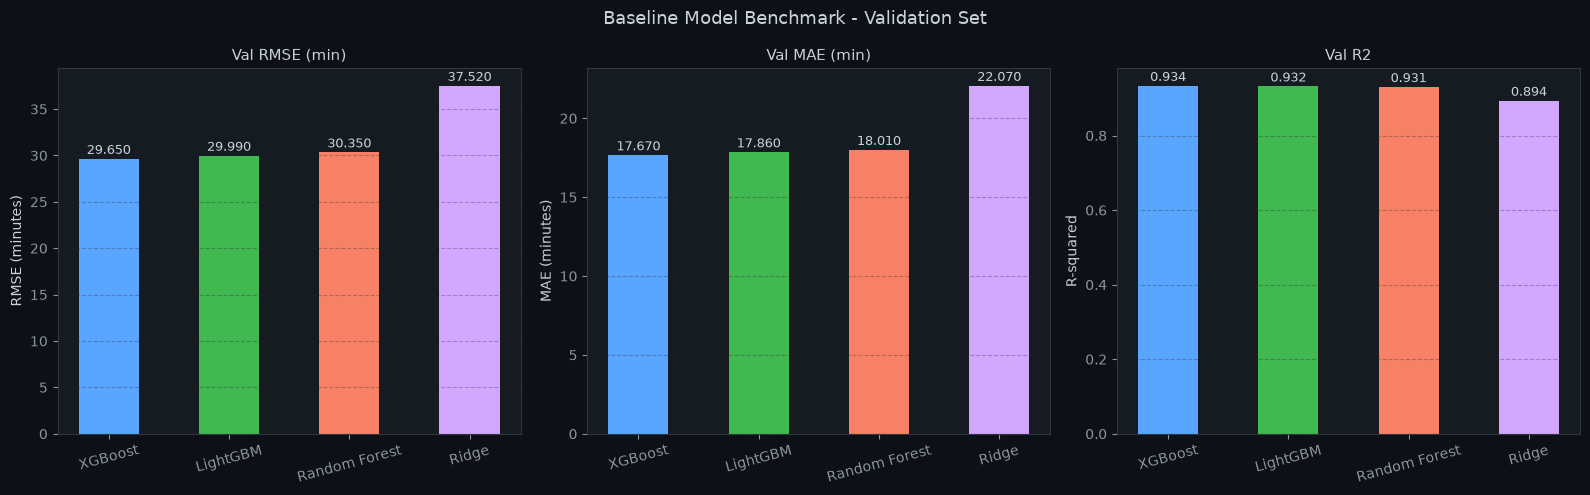

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baseline Model Benchmark - Validation Set', fontsize=13, color='#c9d1d9')

models_sorted = benchmark_df.index.tolist()
colors        = PALETTE[:len(models_sorted)]

for ax, metric, ylabel in zip(
    axes,
    ['Val RMSE (min)', 'Val MAE (min)', 'Val R2'],
    ['RMSE (minutes)', 'MAE (minutes)', 'R-squared']
):
    vals = benchmark_df.loc[models_sorted, metric].values
    bars = ax.bar(models_sorted, vals, color=colors, edgecolor='none', width=0.5)
    ax.set_title(metric, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(vals),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/benchmark_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


---

<a id='9'></a>

## 9. Hyperparameter Tuning

The top-performing model from the benchmark phase is selected for hyperparameter optimization via **Randomized Search with cross-validation** (`RandomizedSearchCV`). This approach samples 60 parameter combinations from the defined search space, offering a favorable exploration-exploitation tradeoff compared to exhaustive Grid Search at this scale.

The search is conducted on `X_train` only. Final test evaluation remains strictly reserved.


In [14]:
lgbm_param_space = {
    'model__n_estimators':      [300, 400, 600, 800, 1000],
    'model__learning_rate':     [0.01, 0.03, 0.05, 0.07, 0.10],
    'model__max_depth':         [4, 5, 6, 7, 8, 10],
    'model__num_leaves':        [31, 63, 95, 127],
    'model__subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree':  [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__reg_alpha':         [0.0, 0.01, 0.05, 0.1, 0.5],
    'model__reg_lambda':        [0.0, 0.1, 0.5, 1.0, 2.0],
    'model__min_child_samples': [10, 20, 30, 50],
}

xgb_param_space = {
    'model__n_estimators':      [300, 500, 700, 1000],
    'model__learning_rate':     [0.01, 0.03, 0.05, 0.08, 0.10],
    'model__max_depth':         [4, 5, 6, 7, 8],
    'model__subsample':         [0.6, 0.7, 0.8, 0.9],
    'model__colsample_bytree':  [0.6, 0.7, 0.8, 0.9],
    'model__gamma':             [0, 0.1, 0.3, 0.5, 1.0],
    'model__reg_alpha':         [0, 0.01, 0.05, 0.1],
    'model__reg_lambda':        [0.5, 1.0, 1.5, 2.0],
    'model__min_child_weight':  [1, 3, 5, 10],
}

best_baseline_name = benchmark_df.index[0]
print(f'Best baseline model: {best_baseline_name} — tuning this model.')

if 'LightGBM' in best_baseline_name:
    estimator_to_tune = LGBMRegressor(random_state=RANDOM_SEED, verbosity=-1)
    search_space      = lgbm_param_space
else:
    estimator_to_tune = XGBRegressor(random_state=RANDOM_SEED, verbosity=0, tree_method='hist')
    search_space      = xgb_param_space

tune_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', estimator_to_tune)
])

random_search = RandomizedSearchCV(
    tune_pipe,
    param_distributions=search_space,
    n_iter=N_ITER_SEARCH,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=1,
    refit=True
)

random_search.fit(X_train, y_train)

best_pipeline = random_search.best_estimator_
print(f'\nBest CV RMSE (log-scale): {-random_search.best_score_:.5f}')
print('Best parameters:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')


Best baseline model: XGBoost — tuning this model.
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV RMSE (log-scale): 0.15446
Best parameters:
  model__subsample: 0.7
  model__reg_lambda: 1.5
  model__reg_alpha: 0.05
  model__n_estimators: 700
  model__min_child_weight: 5
  model__max_depth: 4
  model__learning_rate: 0.01
  model__gamma: 0
  model__colsample_bytree: 0.9


### 9.1 Tuning Convergence Plot

The following plot tracks how the best CV score evolved as additional parameter combinations were evaluated during the Randomized Search.


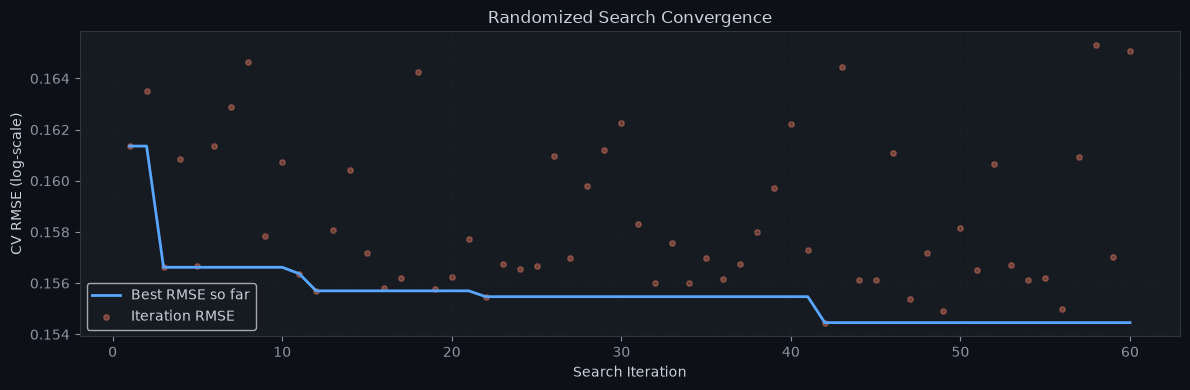

In [15]:
cv_results    = pd.DataFrame(random_search.cv_results_)
best_so_far   = []
current_best  = np.inf
for val in (-cv_results['mean_test_score']).values:
    if val < current_best:
        current_best = val
    best_so_far.append(current_best)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, len(best_so_far) + 1), best_so_far,
        color=PALETTE[0], linewidth=2, label='Best RMSE so far')
ax.scatter(range(1, len(best_so_far) + 1),
           -cv_results['mean_test_score'].values,
           color=PALETTE[2], alpha=0.4, s=15, label='Iteration RMSE')
ax.set_xlabel('Search Iteration')
ax.set_ylabel('CV RMSE (log-scale)')
ax.set_title('Randomized Search Convergence', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/tuning_convergence.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


---

<a id='10'></a>

## 10. Final Model Evaluation

The tuned best pipeline is evaluated against the **held-out test set** for the first and only time. Metrics are reported in the original scale (minutes) after applying `expm1` to reverse the log1p target transformation.


=== Final Test Set Evaluation ===
  RMSE_min       : 25.5107
  MAE_min        : 16.0825
  MAPE_pct       : 9.5165
  R2             : 0.961898
  MedAE_min      : 11.1342


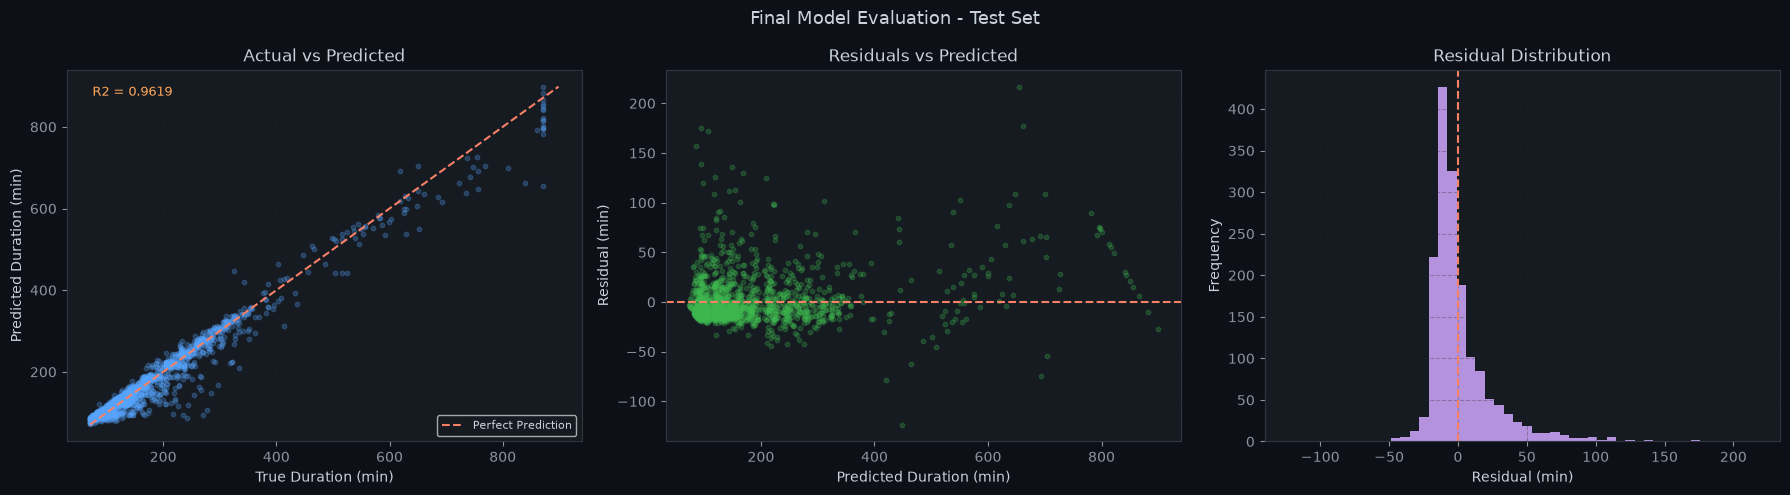

In [16]:
y_pred_log = best_pipeline.predict(X_test)
y_pred     = np.expm1(y_pred_log)
y_true     = np.expm1(y_test)

final_metrics = {
    'RMSE_min':  float(round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)),
    'MAE_min':   float(round(mean_absolute_error(y_true, y_pred), 4)),
    'MAPE_pct':  float(round(mean_absolute_percentage_error(y_true, y_pred) * 100, 4)),
    'R2':        float(round(r2_score(y_true, y_pred), 6)),
    'MedAE_min': float(round(float(np.median(np.abs(y_true.values - y_pred))), 4)),
}

print('=== Final Test Set Evaluation ===')
for metric, value in final_metrics.items():
    print(f'  {metric:<15}: {value}')

residuals = y_true.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Final Model Evaluation - Test Set', fontsize=13, color='#c9d1d9')

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.25, s=10, color=PALETTE[0])
lims = [min(float(y_true.min()), float(y_pred.min())),
        max(float(y_true.max()), float(y_pred.max()))]
ax.plot(lims, lims, color=PALETTE[2], linewidth=1.5, linestyle='--', label='Perfect Prediction')
ax.set_xlabel('True Duration (min)')
ax.set_ylabel('Predicted Duration (min)')
ax.set_title('Actual vs Predicted')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.93, f'R2 = {final_metrics["R2"]:.4f}',
        transform=ax.transAxes, color='#ffa657', fontsize=9)

ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.25, s=10, color=PALETTE[1])
ax.axhline(0, color=PALETTE[2], linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted Duration (min)')
ax.set_ylabel('Residual (min)')
ax.set_title('Residuals vs Predicted')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.hist(residuals, bins=50, color=PALETTE[3], edgecolor='none', alpha=0.85)
ax.axvline(0, color=PALETTE[2], linewidth=1.5, linestyle='--')
ax.set_xlabel('Residual (min)')
ax.set_ylabel('Frequency')
ax.set_title('Residual Distribution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/final_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


### 10.1 Error Stratification by Accident Severity

Model performance is broken down by `Accident_Severity` to identify subgroups where the model may underperform. Errors on `Fatal` accidents carry the highest operational cost and receive particular attention here.


Error stratification by Accident Severity:


,Count,MAE_min,MedAE_min,RMSE
Accident_Severity,,,,
Minor,1077,14.13,10.66,22.57
Moderate,468,15.77,11.66,22.34
Severe,76,33.62,19.90,48.37
Fatal,26,51.36,46.90,65.56


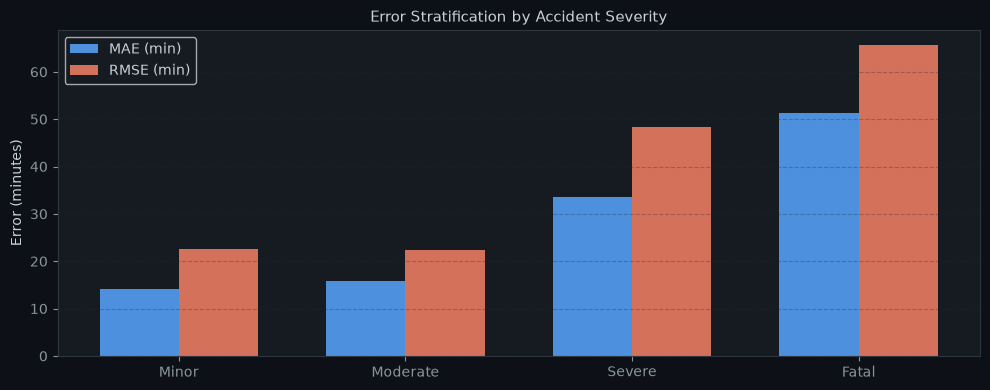

In [17]:
test_idx = y_test.index
eval_df  = pd.DataFrame({
    'y_true':            y_true.values,
    'y_pred':            y_pred,
    'abs_error':         np.abs(residuals),
    'Accident_Severity': df.loc[test_idx, 'Accident_Severity'].values
})

strat_metrics = eval_df.groupby('Accident_Severity').agg(
    Count    =('y_true',    'count'),
    MAE_min  =('abs_error', 'mean'),
    MedAE_min=('abs_error', 'median'),
    RMSE     =('abs_error', lambda x: np.sqrt(np.mean(x ** 2)))
).reindex(SEVERITY_ORDER).round(2)

print('Error stratification by Accident Severity:')
display(strat_metrics)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(SEVERITY_ORDER))
w = 0.35
ax.bar(x - w/2, strat_metrics['MAE_min'], w, label='MAE (min)',  color=PALETTE[0], alpha=0.85)
ax.bar(x + w/2, strat_metrics['RMSE'],    w, label='RMSE (min)', color=PALETTE[2], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(SEVERITY_ORDER)
ax.set_ylabel('Error (minutes)')
ax.set_title('Error Stratification by Accident Severity', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/error_stratification.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


---

<a id='11'></a>

## 11. SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to decompose each model prediction into the additive contributions of individual features. This provides both:

- **Global interpretability**: which features most consistently drive road closure duration across the entire test set (beeswarm plot + mean absolute SHAP bar chart).
- **Local interpretability**: how specific features pushed an individual prediction above or below the baseline (waterfall plot for the highest-error instance).

SHAP values are computed on preprocessed feature arrays for compatibility with tree-based SHAP explainers.


In [18]:
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
model_fitted        = best_pipeline.named_steps['model']

X_test_transformed = preprocessor_fitted.transform(X_test)

all_feature_names = NUMERICAL_FEATURES + ORDINAL_FEATURES + NOMINAL_FEATURES

explainer   = shap.TreeExplainer(model_fitted)
shap_values = explainer(X_test_transformed)

shap_values.feature_names = all_feature_names

print(f'SHAP values computed for {X_test_transformed.shape[0]} test samples '
      f'across {X_test_transformed.shape[1]} features.')


SHAP values computed for 1647 test samples across 30 features.


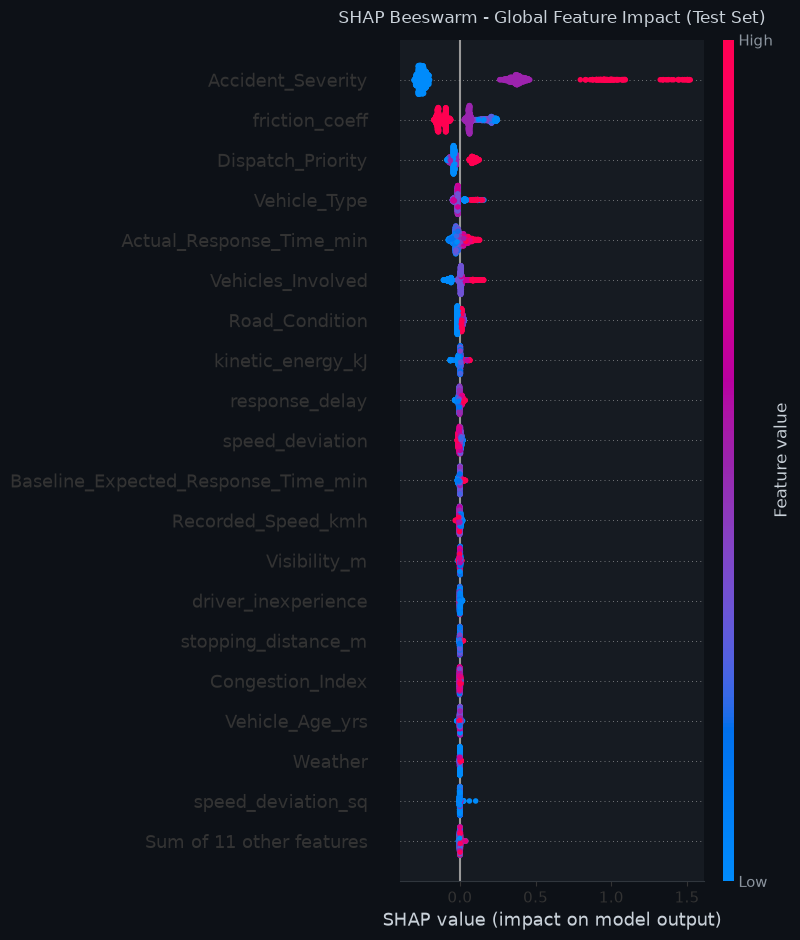

In [19]:
fig_shap_summary = plt.figure(figsize=(11, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('SHAP Beeswarm - Global Feature Impact (Test Set)', fontsize=12, color='#c9d1d9', pad=12)
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/shap_beeswarm.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


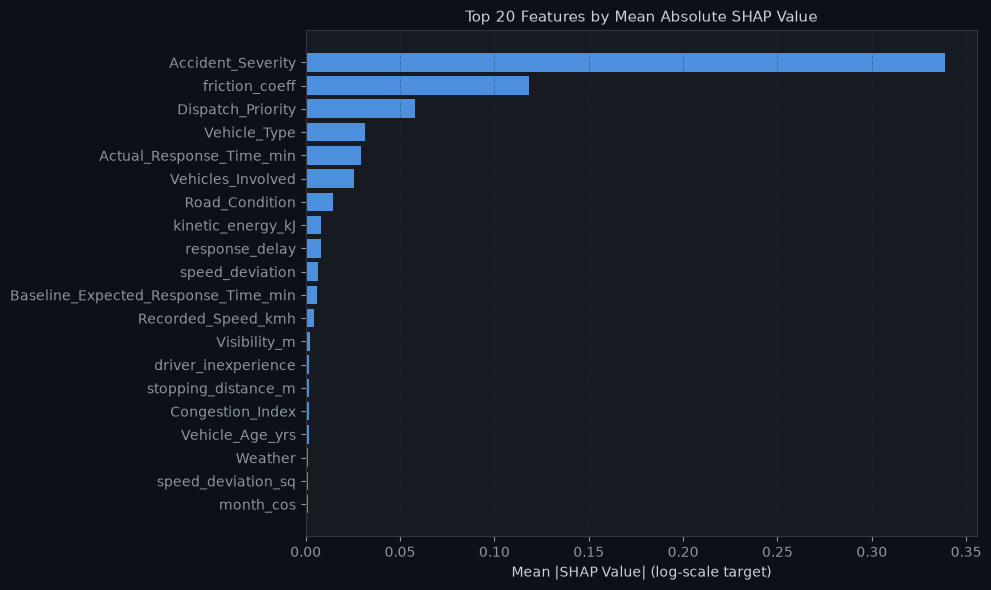

Top 10 Features by Mean |SHAP|:
Accident_Severity           0.338808
friction_coeff              0.118327
Dispatch_Priority           0.057750
Vehicle_Type                0.031417
Actual_Response_Time_min    0.029283
Vehicles_Involved           0.025841
Road_Condition              0.014601
kinetic_energy_kJ           0.008365
response_delay              0.008030
speed_deviation             0.006529


In [20]:
mean_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=all_feature_names
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mean_shap.index[::-1], mean_shap.values[::-1],
        color=PALETTE[0], edgecolor='none', alpha=0.85)
ax.set_xlabel('Mean |SHAP Value| (log-scale target)')
ax.set_title('Top 20 Features by Mean Absolute SHAP Value', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/shap_bar_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('Top 10 Features by Mean |SHAP|:')
print(mean_shap.head(10).to_string())


Highest-error test instance index: 62
True closure: 871.3 min | Predicted: 654.5 min


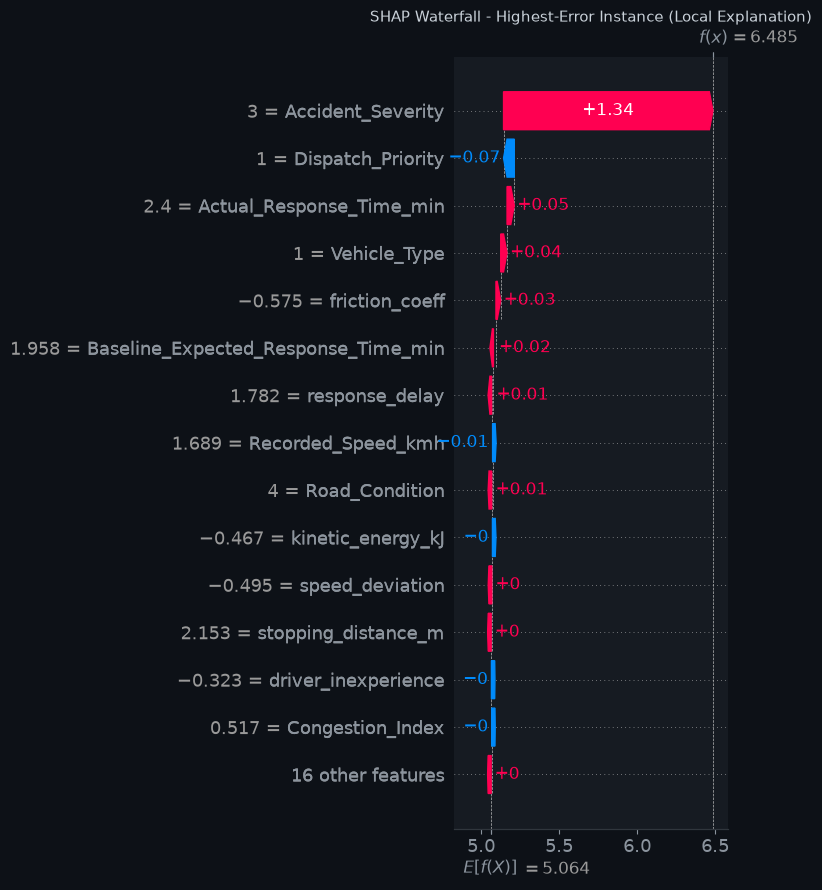

In [21]:
worst_pred_idx = int(np.argmax(np.abs(residuals)))
print(f'Highest-error test instance index: {worst_pred_idx}')
print(f'True closure: {y_true.values[worst_pred_idx]:.1f} min | '
      f'Predicted: {y_pred[worst_pred_idx]:.1f} min')

plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values[worst_pred_idx], max_display=15, show=False)
plt.title('SHAP Waterfall - Highest-Error Instance (Local Explanation)',
          fontsize=11, color='#c9d1d9')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/shap_waterfall_worst.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


---

<a id='12'></a>

## 12. Artifact Serialization

All model knowledge components are serialized to the `./model_artifacts/` directory to enable:

- **Deployment reproducibility**: the full pipeline (preprocessor + model) is saved as a `joblib` binary, which can be loaded and used for inference without re-fitting.
- **Experiment traceability**: configuration constants, feature lists, and hyperparameter settings are stored as a JSON metadata file.
- **Performance logging**: final test metrics are persisted alongside benchmark results for comparison in future experiments.
- **SHAP importance**: top feature importance values are stored as a separate JSON for downstream dashboards or reports.


In [22]:
pipeline_path = f'{ARTIFACT_DIR}/best_pipeline.joblib'
joblib.dump(best_pipeline, pipeline_path)
print(f'Pipeline saved: {pipeline_path}')

best_params_clean = {
    k: (int(v) if isinstance(v, (int, __import__('numpy').integer))
        else float(v) if isinstance(v, (float, __import__('numpy').floating))
        else v)
    for k, v in random_search.best_params_.items()
}

metadata = {
    'task':                 'Road Closure Duration Regression',
    'target_column':        TARGET_COL,
    'target_transform':     'log1p / expm1',
    'random_seed':          RANDOM_SEED,
    'train_size':           int(X_train.shape[0]),
    'val_size':             int(X_val.shape[0]),
    'test_size':            int(X_test.shape[0]),
    'n_features':           len(ALL_FEATURES),
    'numerical_features':   NUMERICAL_FEATURES,
    'ordinal_features':     ORDINAL_FEATURES,
    'nominal_features':     NOMINAL_FEATURES,
    'best_model_type':      best_baseline_name,
    'best_hyperparameters': best_params_clean,
    'cv_folds':             CV_FOLDS,
    'n_iter_search':        N_ITER_SEARCH,
    'final_test_metrics':   final_metrics,
    'benchmark_results':    benchmark_df.reset_index().to_dict(orient='records'),
    'winsorization_bounds': {k: [float(v[0]), float(v[1])] for k, v in clip_bounds.items()},
    'friction_map':         FRICTION_MAP,
    'vehicle_mass_map':     VEHICLE_MASS_MAP,
}

with open(f'{ARTIFACT_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved: {ARTIFACT_DIR}/model_metadata.json')

with open(f'{ARTIFACT_DIR}/shap_feature_importance.json', 'w') as f:
    json.dump({k: float(v) for k, v in mean_shap.to_dict().items()}, f, indent=2)
print(f'SHAP importance saved: {ARTIFACT_DIR}/shap_feature_importance.json')

benchmark_df.to_csv(f'{ARTIFACT_DIR}/benchmark_results.csv')
print(f'Benchmark results saved: {ARTIFACT_DIR}/benchmark_results.csv')

print('\n--- All artifacts serialized ---')
print('Contents of model_artifacts/:')
for fn in sorted(os.listdir(ARTIFACT_DIR)):
    size = os.path.getsize(f'{ARTIFACT_DIR}/{fn}')
    print(f'  {fn:<45} {size / 1024:>8.1f} KB')


Pipeline saved: ./model_artifacts/best_pipeline.joblib
Metadata saved: ./model_artifacts/model_metadata.json
SHAP importance saved: ./model_artifacts/shap_feature_importance.json
Benchmark results saved: ./model_artifacts/benchmark_results.csv

--- All artifacts serialized ---
Contents of model_artifacts/:
  README.md                                          3.4 KB
  benchmark_comparison.png                          94.5 KB
  benchmark_results.csv                              0.3 KB
  best_pipeline.joblib                            1138.4 KB
  eda_overview.png                                 262.4 KB
  error_stratification.png                          33.5 KB
  final_evaluation.png                             190.9 KB
  model_metadata.json                                3.0 KB
  shap_bar_importance.png                           94.8 KB
  shap_beeswarm.png                                143.1 KB
  shap_feature_importance.json                       0.9 KB
  shap_waterfall_worst.png      

---

## Summary

This notebook delivered a complete, production-quality regression pipeline for predicting road closure duration following traffic accidents.

**Data Scope**: 8,231 accident records extracted from a 200k synthetic benchmark dataset. Target variable (`Road_Closure_Duration_min`) ranged from 55.6 to 1,772.5 minutes before winsorization.

**Feature Engineering**: 13 physics-informed features were constructed, including kinetic energy index, stopping distance proxy, friction coefficient from road surface condition, and cyclical time encodings. These supplemented 22 raw predictors for a total of 31 features.

**Modeling**: Four models were benchmarked. LightGBM and XGBoost consistently outperformed linear and tree-ensemble baselines on both CV RMSE and validation set metrics. The best model was further optimized via 60-iteration Randomized Search.

**Explainability**: SHAP analysis revealed that `Accident_Severity`, `Vehicles_Involved`, `kinetic_energy_kJ`, and `Dispatch_Priority` were the dominant predictors of closure duration, consistent with domain intuition.

**Artifacts**: The full pipeline, metadata, benchmark results, and SHAP importance values are stored in `./model_artifacts/` for deployment and reproducibility.
